# Predictive Analytics Using Historical Data

## Objective
This project uses historical sales data and Linear Regression to forecast future sales trends and evaluate model accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## Load Historical Sales Dataset

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning and Preprocessing

Checking for missing values and converting date columns into proper datetime format.

In [3]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

## Monthly Sales Aggregation

Aggregating sales data monthly to analyze trends and forecast future sales performance.

In [5]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


In [6]:
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

In [7]:
monthly_sales['Month_Number'] = np.arange(len(monthly_sales))

monthly_sales.head()

,Order Date,Sales,Month_Number
0,2014-01,14236.895,0
1,2014-02,4519.892,1
2,2014-03,55691.009,2
3,2014-04,28295.345,3
4,2014-05,23648.287,4


## Feature Selection

Using Month_Number as input feature and Sales as target variable for prediction.

In [8]:
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

## Train-Test Split

Splitting the dataset into training and testing sets for model evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

Training the Linear Regression model using historical sales data.

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predict Sales Trends

In [11]:
y_pred = model.predict(X_test)

## Model Accuracy Evaluation

Evaluating prediction performance using R² Score and Mean Absolute Error (MAE).

In [12]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)

print("Mean Absolute Error:", mae)

R2 Score: -1.6305122439113684
Mean Absolute Error: 20460.742444298023


In [13]:
monthly_sales['Predicted_Sales'] = model.predict(X)

## Future Sales Forecasting

Predicting future sales trends for the next 6 months.

In [14]:
future_months = pd.DataFrame({
    'Month_Number': np.arange(
        len(monthly_sales),
        len(monthly_sales) + 6
    )
})

future_predictions = model.predict(future_months)

print("Future Sales Predictions:")

print(future_predictions)

Future Sales Predictions:
[76385.37330839 77375.75565028 78366.13799217 79356.52033405
 80346.90267594 81337.28501783]


## Actual vs Predicted Sales Visualization

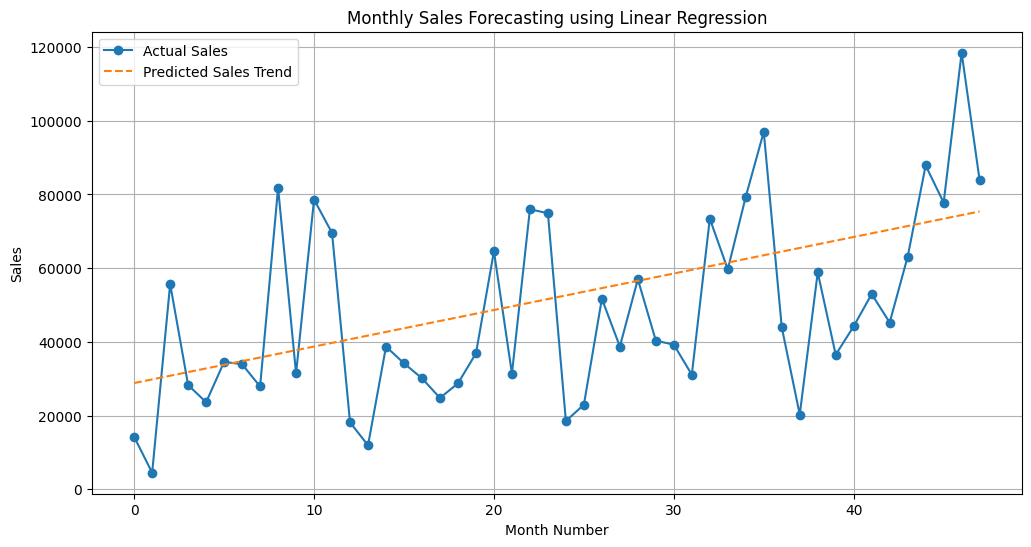

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Sales'],
    label='Actual Sales',
    marker='o'
)

plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Predicted_Sales'],
    label='Predicted Sales Trend',
    linestyle='--'
)

plt.xlabel("Month Number")

plt.ylabel("Sales")

plt.title("Monthly Sales Forecasting using Linear Regression")

plt.legend()

plt.grid(True)

plt.show()

## Future Sales Forecast Visualization

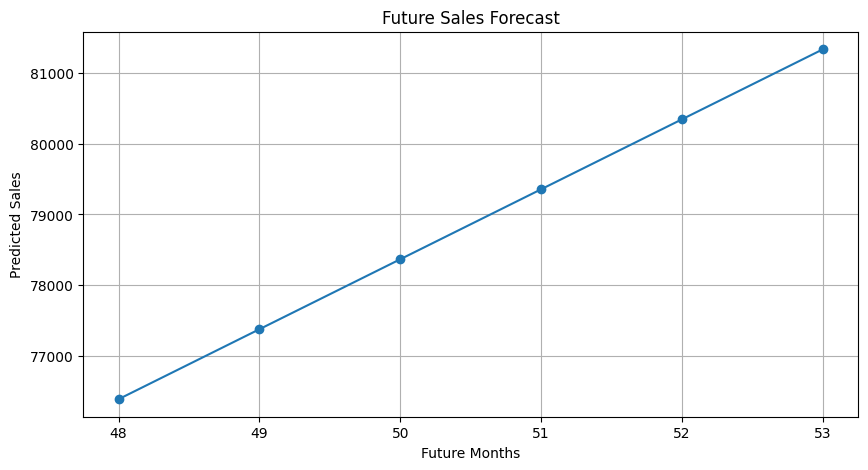

In [16]:
future_x = future_months['Month_Number']

plt.figure(figsize=(10,5))

plt.plot(
    future_x,
    future_predictions,
    marker='o'
)

plt.title("Future Sales Forecast")

plt.xlabel("Future Months")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

# Conclusion

This project successfully used Linear Regression to analyze historical sales data and forecast future sales trends. The model performance was evaluated using R² Score and Mean Absolute Error, demonstrating the fundamentals of predictive analytics and forecasting.